**Tugas 1 - Deep Learning**

**Nama : Kevin Andrian**

**NIM : 24030005**

**Prodi : D3 Teknologi Komputer**

# **A. Instruksi Pengerjaan Soal pertama:**

# **1. Pengambilan Data:**

A. Ambil foto close-up (makro) bagian mata Anda sendiri menggunakan kamera ponsel
(pastikan cahaya cukup).

B. Simpan gambar dalam format .jpg, .png atau lainnya.

C. Muat gambar ke Google Colab.

In [2]:
#Upload Gambar
from google.colab import files
uploaded = files.upload()

Saving kevin.jpg to kevin.jpg


**2. Pra-pemrosesan (Coding):**

A. Ubah gambar menjadi Grayscale untuk mendapatkan nilai intensitas cahaya
tunggal.

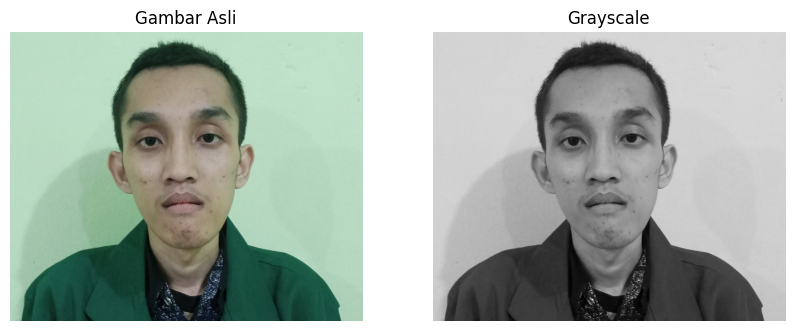

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
# Load gambar
image = cv2.imread('kevin.jpg')
# Ubah ke RGB (karena OpenCV default BGR)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
# Ubah ke grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
# Tampilkan gambar asli & grayscale
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(image_rgb)
plt.title("Gambar Asli")
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale")
plt.axis('off')
plt.show()


C. Lakukan cropping pada area mata saja dengan ukuran terserah, sesuai dengan
gambar saudara X kali Y nya berapa?.

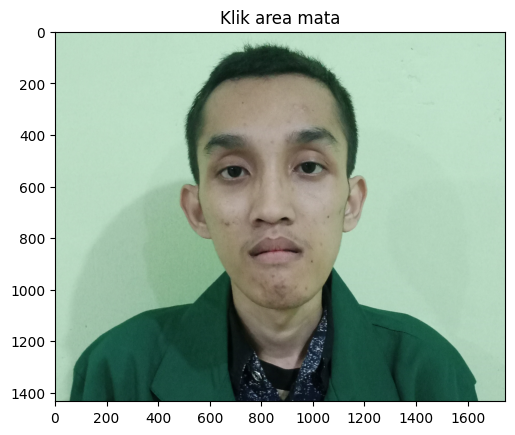

In [4]:
def onclick(event):
    print(f"x = {int(event.xdata)}, y = {int(event.ydata)}")

fig = plt.figure()
plt.imshow(image_rgb)
plt.title("Klik area mata")
cid = fig.canvas.mpl_connect('button_press_event', onclick)
plt.show()

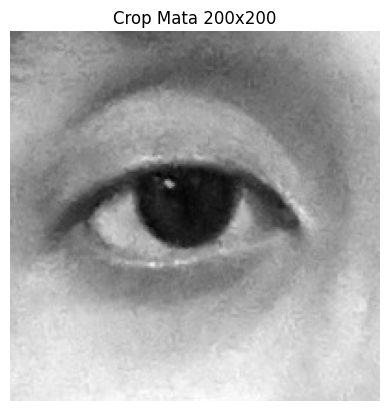

In [5]:
# Tentukan koordinat cropping (contoh manual)
# Silakan sesuaikan jika posisi kurang pas
x, y = 600, 450 # titik awal (kolom, baris)
crop = gray[y:y+200, x:x+200]
# Tampilkan hasil crop
plt.imshow(crop, cmap='gray')
plt.title("Crop Mata 200x200")
plt.axis('off')
plt.show()

**3. Ekstraksi Data:**

A. Tampilkan matriks angka (intensitas piksel) dari area yang dipotong.

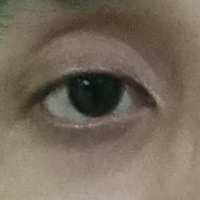

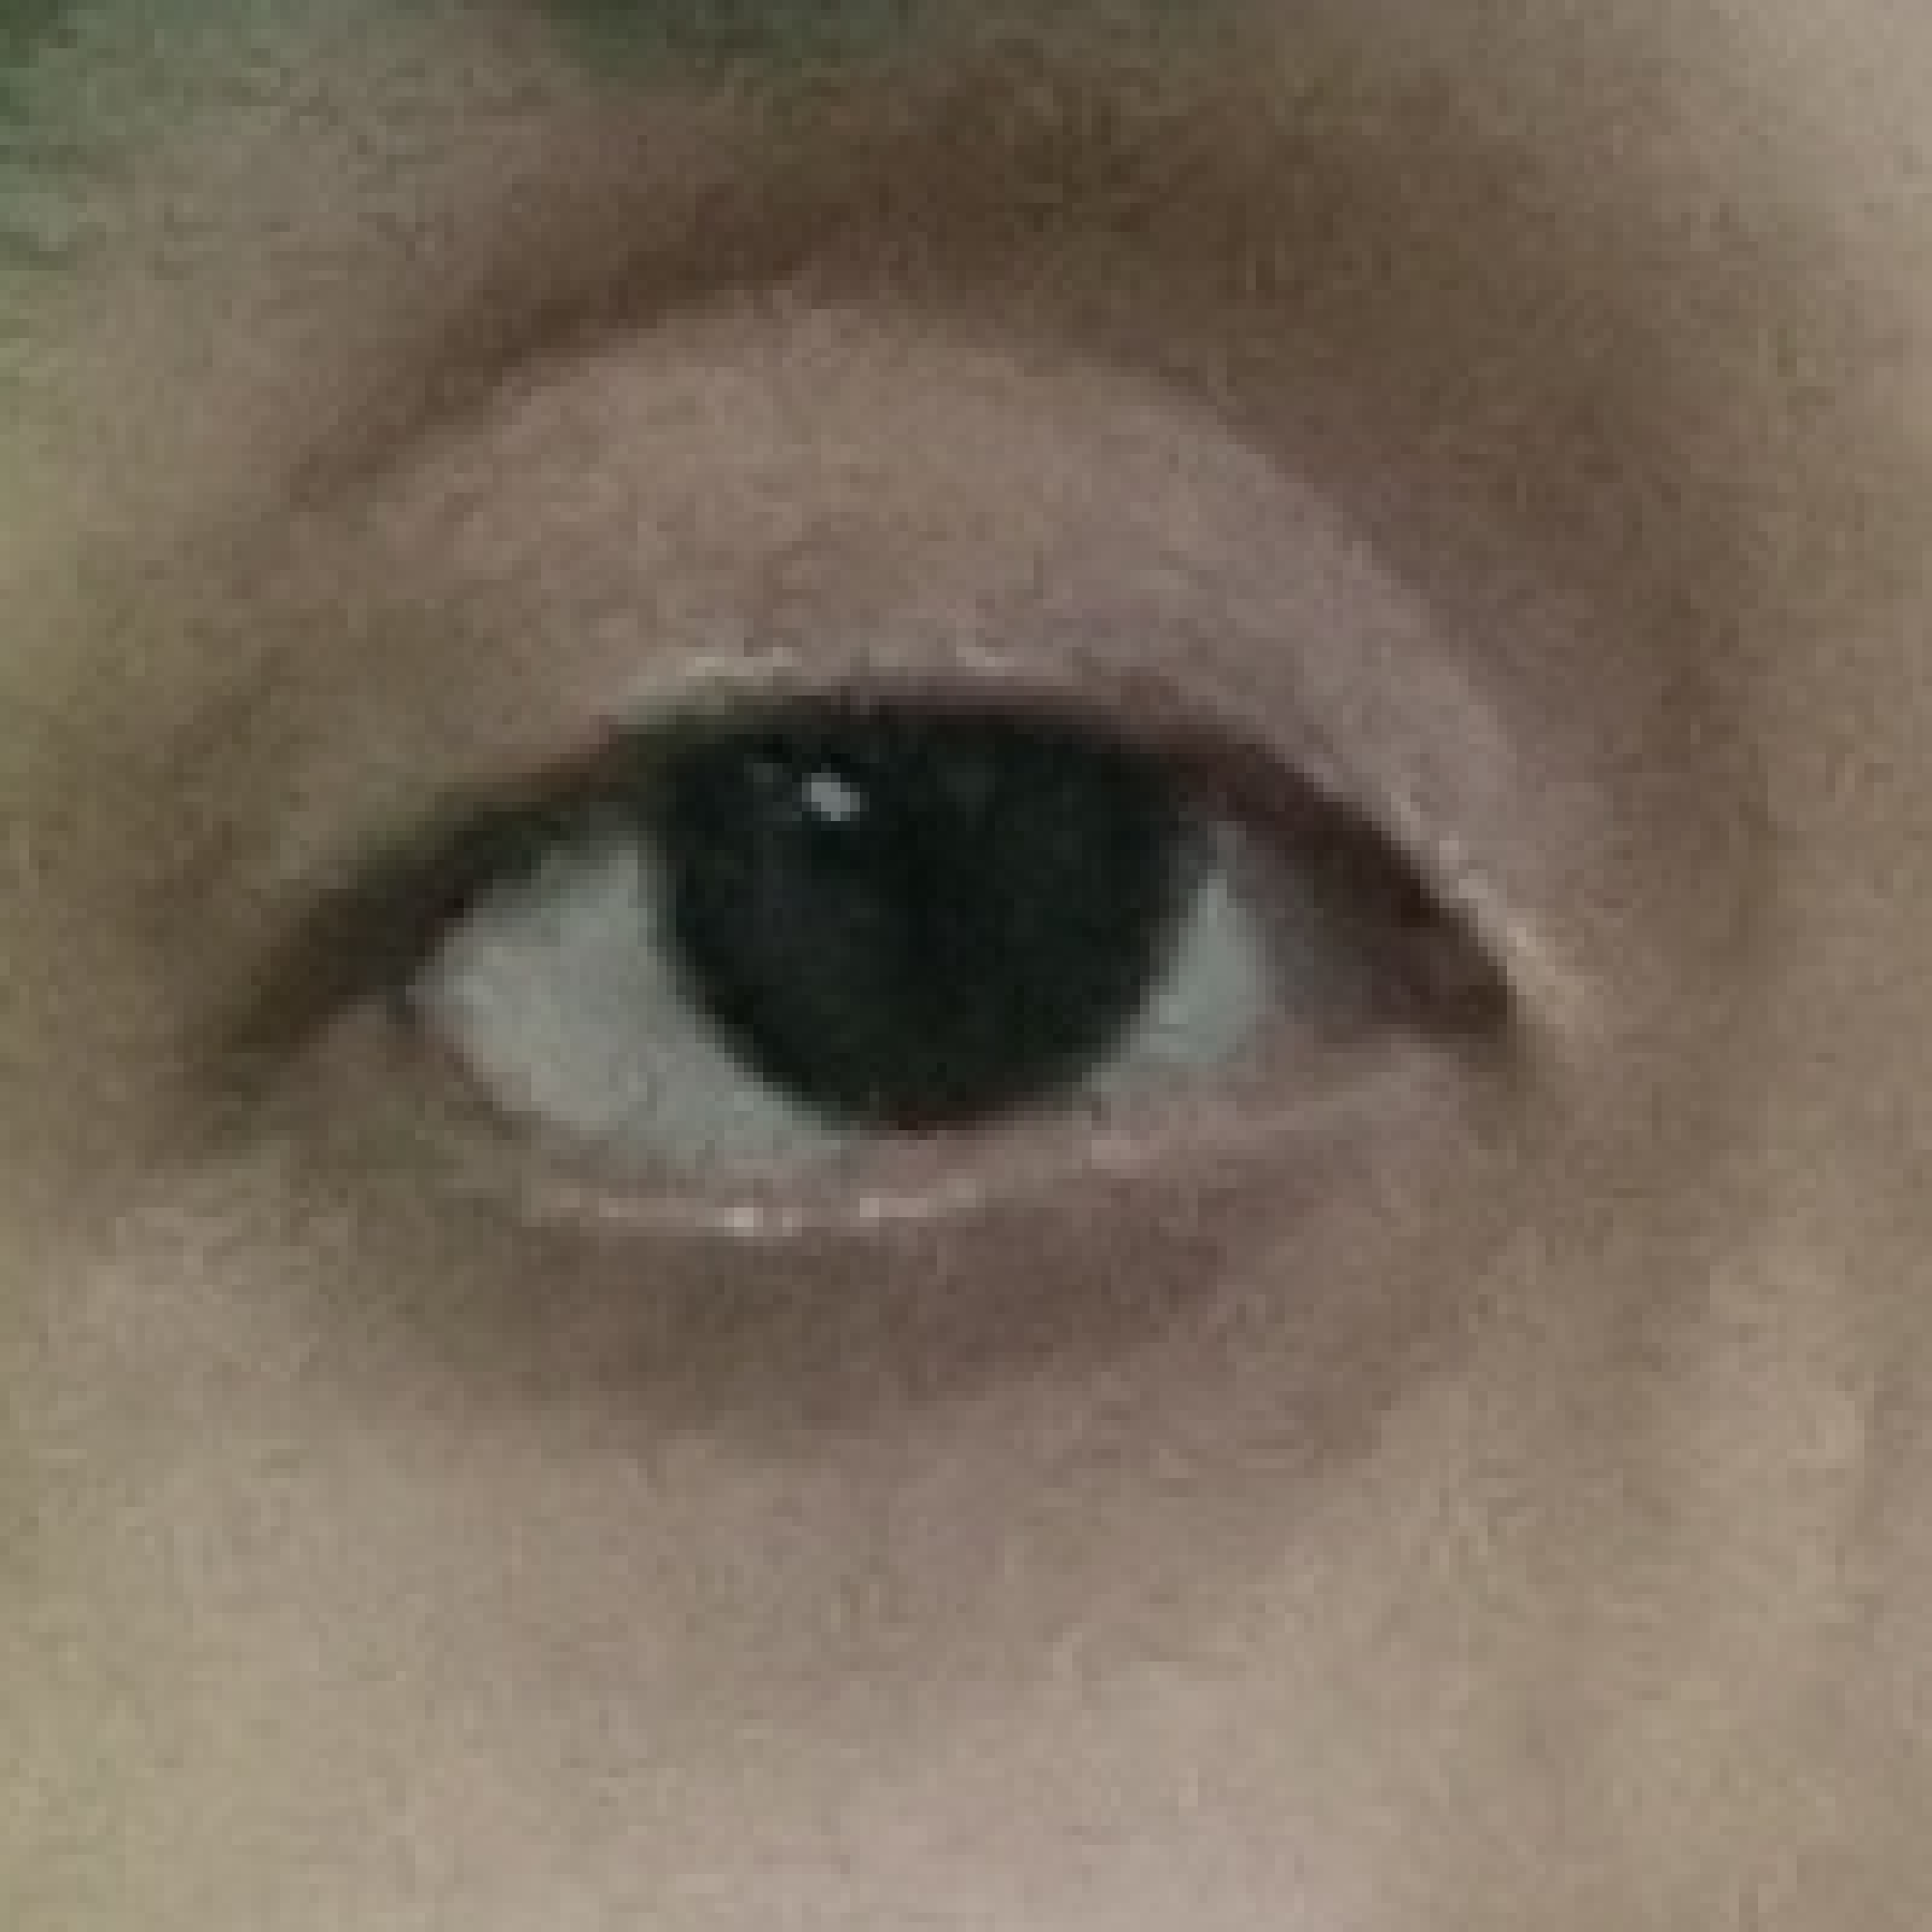

Resolusi area yang dipotong: (200, 200, 3)
Contoh nilai piksel (RGB) di area yang dipotong:
[[[57 81 69]
  [59 83 71]
  [58 79 70]
  [62 83 74]
  [61 82 73]]

 [[53 77 65]
  [57 81 69]
  [60 81 72]
  [62 83 74]
  [61 82 73]]

 [[56 80 70]
  [58 82 72]
  [61 84 76]
  [59 82 74]
  [62 83 75]]

 [[67 91 81]
  [58 82 72]
  [60 83 75]
  [62 85 77]
  [69 90 82]]

 [[69 93 83]
  [61 85 75]
  [65 88 80]
  [72 95 87]
  [76 98 93]]]


In [6]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow # Import the Colab-compatible imshow

# 1. Baca gambar kevin
img = cv2.imread('kevin.jpg')

# Check if the image was loaded successfully
if img is None:
    print("Error: Could not load image 'anjing.jpg'. Please ensure the file is uploaded and accessible.")
else:
    # 2. Tentukan koordinat area yang berbeda.
    # Kali ini, kita akan mencoba area matakevin.
    # Format: [Y_awal:Y_akhir, X_awal:X_akhir]
    startY, endY = 450, 650 # Tentukan baris mata
    startX, endX = 600, 800 # Tentukan kolom (lebar) untuk mata

    # 3. Lakukan pemotongan (Cropping)
    # Kita hanya mengambil sub-matriks dari area yang ditentukan
    mata_kevin = img[startY:endY, startX:endX]

    # 4. Perbesar hasil potongan (PENTING untuk melihat piksel)
    # Jika hanya memotong, hasilnya akan sangat kecil di layar.
    # Kita perbesar 10 kali lipat menggunakan 'INTER_NEAREST'.
    # Teknik ini akan menduplikasi piksel asli tanpa membuatnya blur,
    # sehingga kotak-kotak piksel akan terlihat tajam dan jelas.
    skala = 10
    width = int(mata_kevin.shape[1] * skala)
    height = int(mata_kevin.shape[0] * skala)
    dim = (width, height)

    # Resizing dengan teknik INTER_NEAREST untuk menonjolkan piksel
    mata_pixelated = cv2.resize(mata_kevin, dim, interpolation=cv2.INTER_NEAREST)

    # 5. Tampilkan hasil
    cv2_imshow(mata_kevin) # Use cv2_imshow with only the image array
    cv2_imshow(mata_pixelated) # Use cv2_imshow with only the image array

    # If you want titles, consider using matplotlib.pyplot for display
    # --- Tambahan ---
    # Anda juga bisa melihat nilai angka dari area yang dipotong ini
    print(f"Resolusi area yang dipotong: {mata_kevin.shape}")
    print("Contoh nilai piksel (RGB) di area yang dipotong:")
    print(mata_kevin[0:5, 0:5]) # Tampilkan 5x5 piksel pertama dari area yang dipotong


B. Hitung dan tentukan koordinat nilai piksel minimum (titik gelap pupil) dan nilai
maksimum (titik terang pantulan cahaya)

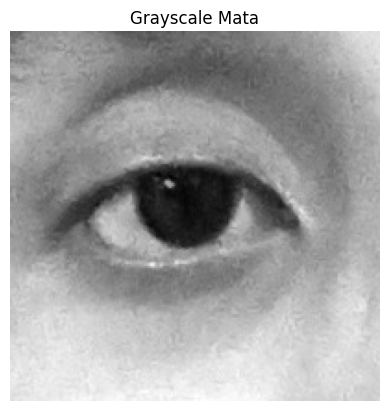

In [ ]:
gray_crop = crop
plt.imshow(gray_crop, cmap='gray')
plt.title("Grayscale Mata")
plt.axis('off')
plt.show()

In [ ]:
max_val = np.max(gray_crop)
min_val = np.min(gray_crop)
min_pos = np.unravel_index(np.argmin(gray_crop), gray_crop.shape)
max_pos = np.unravel_index(np.argmax(gray_crop), gray_crop.shape)
print("Nilai minimum (pupil):", min_val, "di", min_pos)
print("Nilai maksimum (pantulan):", max_val, "di", max_pos)

Nilai minimum (pupil): 10 di (np.int64(78), np.int64(86))
Nilai maksimum (pantulan): 169 di (np.int64(199), np.int64(100))


**4. Visualisasi:**

A. Gunakan library Matplotlib untuk membuat grafik permukaan 3D (3D Surface
Plot).

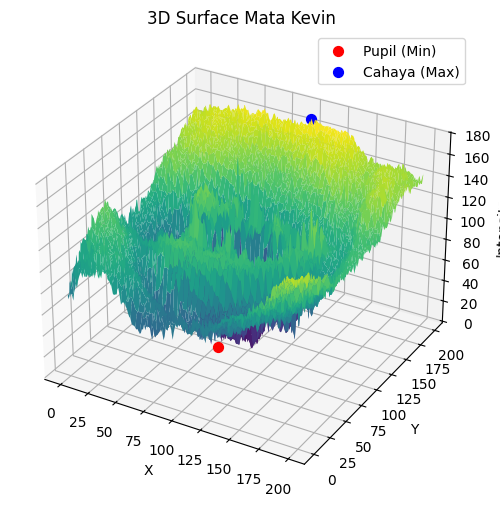

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np
# Pastikan pakai grayscale
Z = gray_crop
# Grid
x = np.arange(0, Z.shape[1])
y = np.arange(0, Z.shape[0])
X, Y = np.meshgrid(x, y)
# Cari min & max
min_val = np.min(Z)
max_val = np.max(Z)
min_pos = np.unravel_index(np.argmin(Z), Z.shape)
max_pos = np.unravel_index(np.argmax(Z), Z.shape)
# Plot 3D
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap='viridis')
# Tandai titik penting
ax.scatter(min_pos[1], min_pos[0], min_val, color='red', s=50, label='Pupil (Min)')
ax.scatter(max_pos[1], max_pos[0], max_val, color='blue', s=50, label='Cahaya (Max)')
ax.set_title("3D Surface Mata Kevin")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Intensitas")
ax.legend()
plt.show()

B. Gunakan colormap (seperti 'viridis') untuk membedakan kedalaman lembah
(pupil) dan ketinggian bukit (tekstur iris).

In [ ]:
print("=== INTERPRETASI 3D ===")
print(f"Nilai minimum: {min_val} pada koordinat {min_pos}")
print("→ Ini merupakan area pupil (bagian paling gelap, terlihat sebagai lembah pada grafik 3D)")
print(f"Nilai maksimum: {max_val} pada koordinat {max_pos}")
print("→ Ini merupakan pantulan cahaya (bagian paling terang, terlihat sebagai puncak pada grafik 3D)")
print("\nDistribusi intensitas:")
print(f"- Rentang intensitas: {min_val} sampai {max_val}")
print("- Area rendah (lembah) = pupil")
print("- Area sedang = iris")
print("- Area tinggi (puncak) = pantulan cahaya")

=== INTERPRETASI 3D ===
Nilai minimum: 10 pada koordinat (np.int64(78), np.int64(86))
→ Ini merupakan area pupil (bagian paling gelap, terlihat sebagai lembah pada grafik 3D)
Nilai maksimum: 169 pada koordinat (np.int64(199), np.int64(100))
→ Ini merupakan pantulan cahaya (bagian paling terang, terlihat sebagai puncak pada grafik 3D)

Distribusi intensitas:
- Rentang intensitas: 10 sampai 169
- Area rendah (lembah) = pupil
- Area sedang = iris
- Area tinggi (puncak) = pantulan cahaya


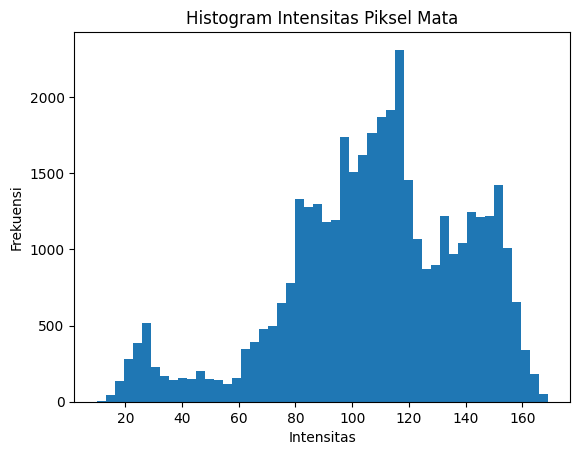

In [ ]:
plt.hist(Z.ravel(), bins=50)
plt.title("Histogram Intensitas Piksel Mata")
plt.xlabel("Intensitas")
plt.ylabel("Frekuensi")
plt.show()

5. Berikan analisis singkat: "Bandingkan bentuk 'lembah' pupil Anda dengan teman
satu kelompok. Apakah bentuknya bulat sempurna atau lonjong? Mengapa?

Dari hasil visualisasi 3D, bentuk lembah pupil tidak sepenuhnya bulat sempurna, melainkan sedikit lonjong.

# **B. Instruksi Pengerjaan Soal kedua:**

**1 Membaca Gambar.**
**Unduh Satu Gambar Foto Presiden Dari Internet Format JPG/PNG.**

In [ ]:
#Upload Gambar
from google.colab import files
uploaded = files.upload()

Saving soekarno.jpg to soekarno.jpg


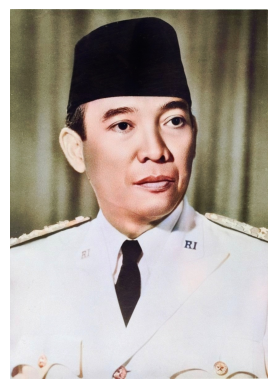

In [ ]:
import cv2
import matplotlib.pyplot as plt
img = cv2.imread("soekarno.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:
print(img.shape)

(917, 640, 3)


a. Berapa ukuran gambar yang dibaca?

jawab : 917 x 640 x 3

b. Berapa jumlah channel warna pada gambar?

jawab : 3 (RGB)

**2) Mengubah Gambar menjadi Grayscale**

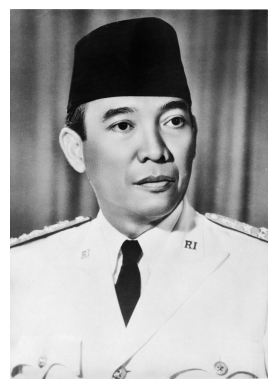

In [ ]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(gray, cmap='gray')
plt.axis("off")
plt.show()

In [ ]:
print(gray.shape)

(917, 640)


1. Apa perbedaan gambar RGB dan grayscale?

jawab : RGB memiliki 3 channel warna (red, green, blue), grayscale hanya hitam putih.

2. Berapa dimensi matriks grayscale

Jawab : 917 x 640

**3) Melihat Nilai Pixel, tampilkan sebagian nilai pixel gambar?**

In [ ]:
print(gray[0:5,0:5])

[[222 172 161 174 164]
 [146 118 120 125 115]
 [122 120 130 125 116]
 [126 127 131 119 115]
 [135 131 127 118 117]]


1) Mengapa nilai pixel berada pada rentang 0–255?

Jawab : Karena dihitung per byte dan 1 byte 8 bit sehingga 2 pangkat 8 = 256 (0-255)

2) Nilai berapa yang menunjukkan warna hitam?

Jawab : 0

3) Nilai berapa yang menunjukkan warna putih?

Jawab : 255

**4) Mengubah Intetitas Pixel, buat gambar menjadi lebih terang.....**

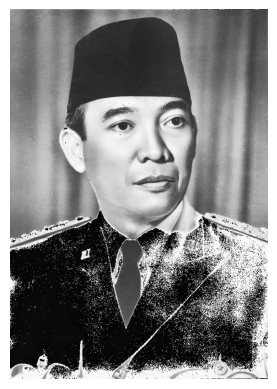

In [ ]:
bright = gray + 30
plt.imshow(bright, cmap='gray')
plt.axis("off")
plt.show()

1. Apa yang terjadi pada gambar?

Jawab : Gambar menjadi lebih terang

2. Mengapa gambar menjadi lebih terang?

Jawab : Karena nilai kecerahan pada gambar ditambah 50 sehingga gambar menjadi lebih terang

**5) Cropping Gambar, Ambil sebagian area gambar.**

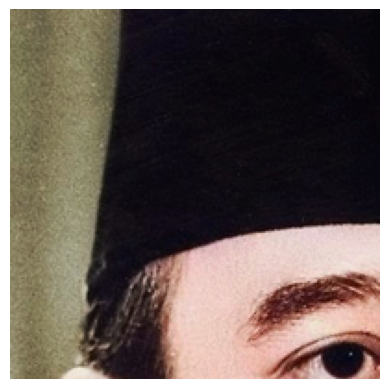

In [ ]:
crop = img[100:300,100:300]
plt.imshow(crop)
plt.axis("off")
plt.show()

1. Bagian gambar apa yang terpotong?

Jawab : Bagian kiri atas

2. Berapa ukuran matriks hasil crop?

Jawab : 200 x 200 x3

**6) Cropping Gambar, Ambil sebagian area gambar.**

In [ ]:
import numpy as np
vector = gray.flatten()
print(vector.shape)

(586880,)


Jika ukuran gambar: 28 × 28 pixel
Berapa panjang vektornya?

Jawab : 28 x 28 = 784

**7) Analisis, Jelaskan dengan bahasa sendiri**

1. Mengapa gambar dapat direpresentasikan sebagai matriks?

Jawab : karena gambar tersusun dari pixel yang memiliki nilai yang bisa di representasikan sebagai matriks

2. Mengapa nilai pixel digunakan sebagai input Deep Learning?

Jawab : Karena deep learning / komputer hanya bisa membaca dan memproses nilai angka saja.

3. Apa hubungan antara pixel dan fitur gambar?

Jawab : pixel bisa diartikan data mentah, fitur adalah pola dari pixel bisa berupa bentuk

**C. Instruksi Pengerjaan Soal Ketiga:**

Carilah sebuah gambar wajah dalam kondisi blur, setiap mahasiswa dan mahasiswi
berbeda. Lakukan perbaikan citra menggunakan metode matriks (sharpening),
peningkatan kontras RGB, dan edge detection. Bandingkan hasilnya dan jelaskan
analisis Anda.

In [ ]:
#Upload Gambar
from google.colab import files
uploaded = files.upload()

Saving images.jpg to images (2).jpg


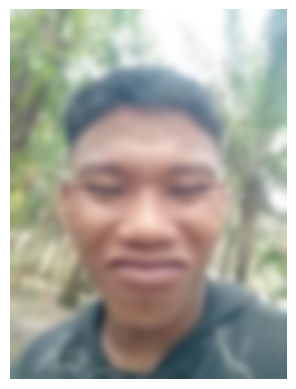

In [ ]:
#Load Gambar Blur
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_orig = cv2.imread('images (2).jpg')
img_orig = cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)
img_origg = cv2.GaussianBlur(img_orig, (15, 15), 0)

plt.imshow(img_origg)
plt.axis("off")
plt.show()

(np.float64(-0.5), np.float64(193.5), np.float64(258.5), np.float64(-0.5))

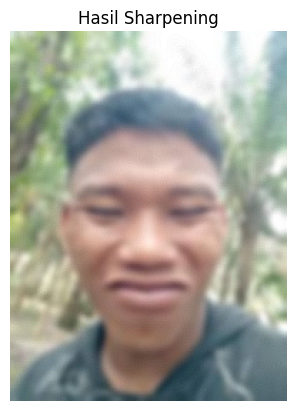

In [ ]:
# Sharpening (Metode Matriks)
kernel_sharpening = np.array([[-1, -1, -1],
                              [-1,  9, -1],
                              [-1, -1, -1]])
img_sharpened = cv2.filter2D(img_blur, -1, kernel_sharpening)

plt.imshow(img_sharpened)
plt.title("Hasil Sharpening")
plt.axis("off")

(np.float64(-0.5), np.float64(193.5), np.float64(258.5), np.float64(-0.5))

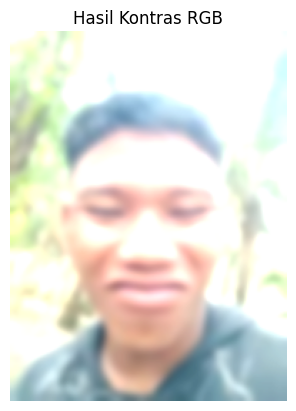

In [ ]:
# Kontras RGB
img_contrast = cv2.convertScaleAbs(img_blur, alpha=1.5, beta=10)

plt.imshow(img_contrast)
plt.title("Hasil Kontras RGB")
plt.axis("off")

(np.float64(-0.5), np.float64(193.5), np.float64(258.5), np.float64(-0.5))

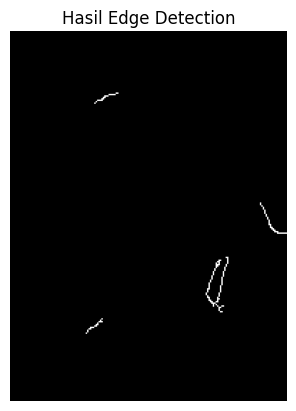

In [ ]:
# Edge Detection
img_gray = cv2.cvtColor(img_blur, cv2.COLOR_RGB2GRAY)
edges = cv2.Canny(img_gray, 50, 150)

plt.imshow(edges, cmap='gray')
plt.title("Hasil Edge Detection")
plt.axis("off")

(np.float64(-0.5), np.float64(193.5), np.float64(258.5), np.float64(-0.5))

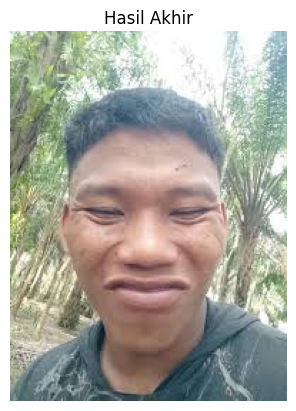

In [ ]:
plt.imshow(img_orig)
plt.title("Hasil Akhir")
plt.axis("off")